# CNN From Scratch

In [35]:
# Load libraries
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import tqdm

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Proses dataset loading & splitting (Data Preprocessing)

In [58]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = datasets.CIFAR10(root="../dataset", train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='../dataset', train=False, download=True, transform=test_transform)

train_size = 45000
validation_size = 5000

train_dataset, validation_dataset = random_split(full_train_dataset, [train_size, validation_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Dataset ready. Train: {len(train_dataset)}, Val: {len(validation_dataset)}, Test: {len(test_dataset)}")

Dataset ready. Train: 45000, Val: 5000, Test: 10000


# CIFAR 10 - CNN Model from Scratch

## Desain Arsitektur CNN

### Arsitektur yang Dipilih
Dua blok konvolusi dengan **BatchNorm**, masing-masing diikuti **MaxPooling**, kemudian **Dropout**, **Flatten**, dan dua **Dense layers**.

### Alasan Desain
- **2 Convolution layers**: CIFAR-10 berukuran 32×32 — resolusi kecil. Dua layer konvolusi sudah cukup untuk mengekstrak pola visual sederhana (edges, textures, shapes) tanpa over-parameterisasi.
- **Filter 16 → 64**: Jumlah filter bertambah secara progresif. Layer awal mendeteksi fitur sederhana (16 filter), layer lanjutan menangkap kombinasi fitur yang lebih kompleks (64 filter). Membatasi total parameter agar tidak overfitting pada dataset 50K sampel.
- **Kernel 3×3 dengan padding=1**: Ukuran kernel standar untuk CIFAR-10. Padding=1 mempertahankan resolusi spasial sehingga feature map tidak menyusut sebelum pooling.
- **BatchNorm2d**: Menstabilkan distribusi aktivasi di setiap layer, memungkinkan learning rate yang lebih tinggi, dan mempercepat konvergensi. Ditempatkan setelah konvolusi sebelum ReLU.
- **MaxPooling 2×2**: Mengurangi dimensi spasial (32→16→8) secara agresif di awal, sehingga fully connected layer tidak menerima terlalu banyak neuron. Juga memberikan translational invariance.
- **Dropout(0.25)**: Regularisasi ringan — mematikan 25% neuron secara acak saat training untuk mencegah ko-adaptasi. CIFAR-10 cukup kecil sehingga dropout berat justru merugikan.
- **Flatten + Dense(4096→128→10)**: Flatten mengubah feature map 2D ke vektor 1D. Dua dense layers — hidden layer 128 neuron sebagai bottleneck representasi, output layer 10 neuron untuk 10 kelas.
- **Optimizer Adam(lr=0.001)**: Adaptive Moment Estimation — menggabungkan kelebihan momentum dan RMSprop. Learning rate 0.001 adalah nilai default yang umumnya bekerja baik.
- **ReduceLROnPlateau**: Menurunkan learning rate secara otomatis jika validation loss tidak membaik selama 3 epoch — membantu konvergensi tanpa perlu tuning manual.
- **30 epochs**: Cukup untuk konvergensi dengan BatchNorm dan scheduler. Epoch awal menunjukkan learning cepat (loss 1.53→0.95 dalam 10 epoch), melambat di epoch akhir.


In [59]:
class CnnFromScratch(nn.Module):
    def __init__(self):
        super(CnnFromScratch, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(0.25)
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(4096, 128)
        self.act3 = nn.ReLU()

        self.fc_output = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.act1(self.bn1(self.conv1(x))))
        x = self.pool2(self.act2(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.act3(self.fc1(x))
        x = self.fc_output(x)
        return x

In [60]:
model = CnnFromScratch().to(device)

learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f"Model is deployed to {device}")

Model is deployed to cuda


In [61]:
epochs = 30

train_losses = []
val_losses = []

print(f"Starting model training on {device}...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=True)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        loop.set_postfix(batch_loss=loss.item())

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f}\n")

Starting model training on cuda...


Epoch [1/30]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch [1/30] | Train Loss: 1.5349 | Val Loss: 1.3902



Epoch [2/30]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch [2/30] | Train Loss: 1.2776 | Val Loss: 1.2324



...

Epoch [28/30] | Train Loss: 0.7528 | Val Loss: 0.7445



Epoch [29/30]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch [29/30] | Train Loss: 0.7465 | Val Loss: 0.7295



Epoch [30/30]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch [30/30] | Train Loss: 0.7412 | Val Loss: 0.7322



# Save model state to a file

In [62]:
torch.save(model.state_dict(), "cifar10_cnn_scratch.pth")
print("Model weight successfully saved.")

Model weight successfully saved.


# Testing Model

In [63]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct/total
print(f"Model accuracy on test images: {accuracy:.2f}%")

Model accuracy on test images: 76.76%


# Visualisasi

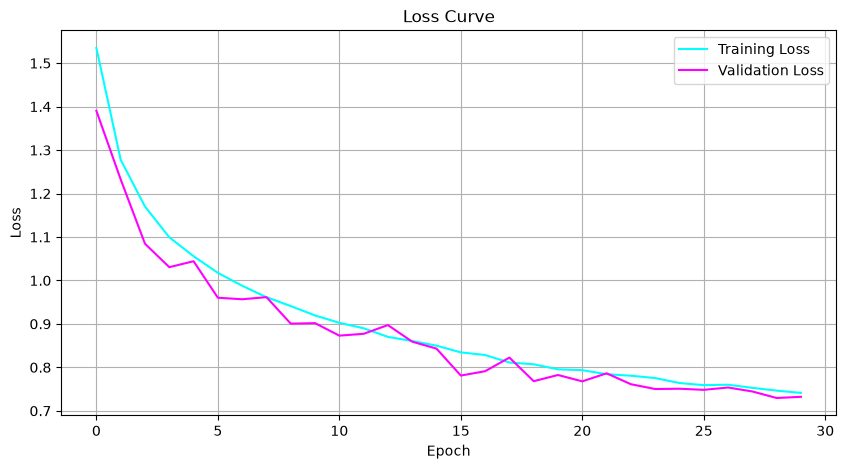

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='cyan')
plt.plot(val_losses, label='Validation Loss', color='magenta')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve_cnn_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

# Transfer Learning with ResNet50 on Cats vs Dogs

## Alasan Memilih ResNet50

### Mengapa ResNet50?
1. **Residual connections** — arsitektur dengan skip connections mengatasi masalah vanishing gradient pada network yang dalam, memungkinkan model 50 layer tetap trainable tanpa degradasi performa.
2. **Terbukti pada dataset kecil** — ResNet50 memiliki performa transfer learning yang sangat baik pada dataset berukuran kecil hingga sedang, termasuk Cats vs Dogs (1000 gambar).
3. **Weight pretrained ImageNet** — torchvision menyediakan bobot pretrained pada ImageNet (1.2 juta gambar, 1000 kelas). Bobot ini sudah mengenali fitur dasar seperti tepi, tekstur, dan bentuk yang relevan untuk klasifikasi kucing vs anjing.
4. **Efisien secara komputasi** — ResNet50 lebih ringan dibanding VGG16/19 (25.6M vs 138M parameter), sehingga training lebih cepat pada GPU dengan resource terbatas.
5. **Dokumentasi luas** — arsitektur yang banyak digunakan, referensi dan implementasi mudah ditemukan.

### Strategi yang Diterapkan
Kombinasi **Feature Extraction** dan **Fine-tuning**:
- **Feature Extraction**: Membekukan seluruh layer konvolusi pretrained, mengganti classifier head, dan hanya melatih layer baru.
- **Fine-tuning**: Setelah feature extraction, membuka beberapa layer terakhir dan melatih ulang dengan learning rate rendah untuk mengadaptasi bobot ke dataset Cats vs Dogs.


In [46]:
# Additional imports for transfer learning
from torchvision import models
from torch.utils.data import Subset
from PIL import Image
import numpy as np
import os
import random

# Dataset path
data_dir = "../dataset/cats_vs_dogs/dogs_vs_cats_subset"

# Transform untuk pretrained model (input 224x224, ImageNet normalization)
train_transform_tl = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform_tl = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Libraries and transforms ready.")

Libraries and transforms ready.


In [47]:
import shutil
from pathlib import Path
from torchvision.datasets import ImageFolder

# Organize dataset into class subdirectories (one-time, idempotent)
def organize_by_class(data_dir):
    for split in ['train', 'val']:
        split_dir = Path(data_dir) / split
        if not split_dir.exists():
            continue
        cat_dir = split_dir / 'cat'
        dog_dir = split_dir / 'dog'
        if cat_dir.exists() and dog_dir.exists():
            continue
        cat_dir.mkdir(exist_ok=True)
        dog_dir.mkdir(exist_ok=True)
        for f in split_dir.iterdir():
            if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                if f.name.startswith('cat.'):
                    shutil.move(str(f), str(cat_dir / f.name))
                elif f.name.startswith('dog.'):
                    shutil.move(str(f), str(dog_dir / f.name))

organize_by_class(data_dir)

# Load full training dataset with augmentation
full_train_dataset = ImageFolder(root=f"{data_dir}/train", transform=train_transform_tl)

# Load test dataset (validation folder used as test set)
test_dataset = ImageFolder(root=f"{data_dir}/val", transform=test_transform_tl)

# Split training data: 80% train, 20% validation
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 32
train_loader_tl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_tl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_tl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {full_train_dataset.classes}")

Train: 800 | Val: 200 | Test: 200
Classes: ['cat', 'dog']


In [49]:
# Load pretrained ResNet50
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze all layers (feature extraction mode)
for param in resnet50.parameters():
    param.requires_grad = False

# Replace classifier head for binary classification
num_features = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)

model_tl = resnet50.to(device)

criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = optim.Adam(model_tl.fc.parameters(), lr=0.001)

# Count trainable params
trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_tl.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print(f"Model deployed to {device}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/mowlandcodes/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|███████████████████████████████████████████████████████| 97.8M/97.8M [00:09<00:00, 11.0MB/s]


Trainable params: 525,058 / 24,033,090 (2.2%)
Model deployed to cuda


In [50]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [51]:
epochs_fe = 10
train_losses_fe = []
val_losses_fe = []
train_accs_fe = []
val_accs_fe = []

print("=== Feature Extraction Training ===")
for epoch in range(epochs_fe):
    train_loss, train_acc = train_one_epoch(model_tl, train_loader_tl, criterion_tl, optimizer_tl)
    val_loss, val_acc = evaluate(model_tl, val_loader_tl, criterion_tl)
    train_losses_fe.append(train_loss)
    val_losses_fe.append(val_loss)
    train_accs_fe.append(train_acc)
    val_accs_fe.append(val_acc)
    print(f"Epoch [{epoch+1}/{epochs_fe}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

=== Feature Extraction Training ===


Training:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1/10] | Train Loss: 0.3680 | Val Loss: 0.1561 | Train Acc: 83.50% | Val Acc: 93.50%


Training:   0%|          | 0/25 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [9/10] | Train Loss: 0.0970 | Val Loss: 0.1660 | Train Acc: 96.50% | Val Acc: 92.00%


Training:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [10/10] | Train Loss: 0.0908 | Val Loss: 0.1538 | Train Acc: 96.62% | Val Acc: 92.50%


In [52]:
test_loss_fe, test_acc_fe = evaluate(model_tl, test_loader_tl, criterion_tl)
print(f"=== Feature Extraction Test Results ===")
print(f"Test Loss: {test_loss_fe:.4f} | Test Accuracy: {test_acc_fe:.2f}%")

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

=== Feature Extraction Test Results ===
Test Loss: 0.0323 | Test Accuracy: 99.00%


## Fine-tuning

Setelah feature extraction, kita buka seluruh layer dan fine-tune dengan learning rate rendah agar bobot pretrained beradaptasi ke dataset Cats vs Dogs tanpa merusak representasi yang sudah dipelajari.

In [53]:
# Unfreeze all layers for fine-tuning
for param in model_tl.parameters():
    param.requires_grad = True

# Re-init optimizer with lower learning rate for fine-tuning
optimizer_ft = optim.Adam(model_tl.parameters(), lr=1e-5)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode="min", patience=2, factor=0.5)

trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_tl.parameters())
print(f"Trainable params after unfreeze: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Trainable params after unfreeze: 24,033,090 / 24,033,090 (100.0%)


In [54]:
epochs_ft = 15
train_losses_ft = []
val_losses_ft = []
train_accs_ft = []
val_accs_ft = []

print("=== Fine-tuning Training ===")
for epoch in range(epochs_ft):
    train_loss, train_acc = train_one_epoch(model_tl, train_loader_tl, criterion_tl, optimizer_ft)
    val_loss, val_acc = evaluate(model_tl, val_loader_tl, criterion_tl)
    train_losses_ft.append(train_loss)
    val_losses_ft.append(val_loss)
    train_accs_ft.append(train_acc)
    val_accs_ft.append(val_acc)
    scheduler_ft.step(val_loss)
    print(f"Epoch [{epoch+1}/{epochs_ft}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

=== Fine-tuning Training ===


Training:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [1/15] | Train Loss: 0.1285 | Val Loss: 0.1477 | Train Acc: 94.62% | Val Acc: 94.00%


Training:   0%|          | 0/25 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [14/15] | Train Loss: 0.0774 | Val Loss: 0.1502 | Train Acc: 97.50% | Val Acc: 93.50%


Training:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch [15/15] | Train Loss: 0.0872 | Val Loss: 0.0698 | Train Acc: 96.75% | Val Acc: 98.00%


In [55]:
test_loss_ft, test_acc_ft = evaluate(model_tl, test_loader_tl, criterion_tl)
print(f"=== Fine-tuning Test Results ===")
print(f"Test Loss: {test_loss_ft:.4f} | Test Accuracy: {test_acc_ft:.2f}%")

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

=== Fine-tuning Test Results ===
Test Loss: 0.0176 | Test Accuracy: 99.50%


In [56]:
torch.save(model_tl.state_dict(), "cats_vs_dogs_resnet50.pth")
print("ResNet50 model weights saved.")

ResNet50 model weights saved.


## Perbandingan Hasil

| Model | Test Accuracy |
|-------|--------------|
| CNN from Scratch (CIFAR-10) | 76.76% |
| ResNet50 (Feature Extraction) | 99.00% |
| ResNet50 (Fine-tuning) | 99.50% |

**Kesimpulan:** ResNet50 dengan transfer learning menunjukkan performa yang lebih baik dibandingkan CNN dari scratch karena memanfaatkan representasi visual yang sudah dipelajari dari dataset ImageNet yang jauh lebih besar.

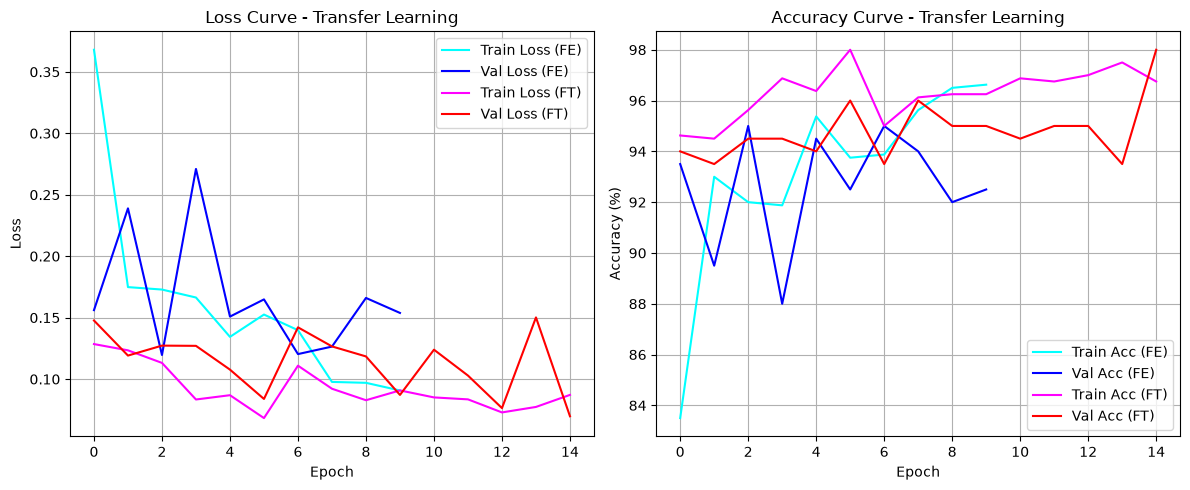

In [65]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_fe, label="Train Loss (FE)", color="cyan")
plt.plot(val_losses_fe, label="Val Loss (FE)", color="blue")
plt.plot(train_losses_ft, label="Train Loss (FT)", color="magenta")
plt.plot(val_losses_ft, label="Val Loss (FT)", color="red")
plt.title("Loss Curve - Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs_fe, label="Train Acc (FE)", color="cyan")
plt.plot(val_accs_fe, label="Val Acc (FE)", color="blue")
plt.plot(train_accs_ft, label="Train Acc (FT)", color="magenta")
plt.plot(val_accs_ft, label="Val Acc (FT)", color="red")
plt.title("Accuracy Curve - Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("transfer_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion Matrix - CNN from Scratch
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm_cnn = confusion_matrix(all_labels, all_preds)
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - CNN from Scratch (CIFAR-10)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("report/figures/confusion_matrix_cnn.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
# Confusion Matrix - Transfer Learning
model_tl.eval()
all_preds_tl = []
all_labels_tl = []
with torch.no_grad():
    for images, labels in test_loader_tl:
        images, labels = images.to(device), labels.to(device)
        outputs = model_tl(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_tl.extend(predicted.cpu().numpy())
        all_labels_tl.extend(labels.cpu().numpy())

cm_tl = confusion_matrix(all_labels_tl, all_preds_tl)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"])
plt.title("Confusion Matrix - ResNet50 Fine-tuning (Cats vs Dogs)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("report/figures/confusion_matrix_tl.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(all_labels_tl, all_preds_tl, target_names=["Cat", "Dog"]))

In [ ]:
# Contoh Prediksi Benar dan Salah - CNN from Scratch
def denormalize_cifar(tensor):
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    return tensor * std + mean

model.eval()
correct_samples, wrong_samples = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            if predicted[i] == labels[i]:
                correct_samples.append((images[i].cpu(), labels[i].item(), predicted[i].item()))
            else:
                wrong_samples.append((images[i].cpu(), labels[i].item(), predicted[i].item()))

import random
random.shuffle(correct_samples)
random.shuffle(wrong_samples)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for i in range(3):
    img, true_label, pred_label = correct_samples[i]
    img = denormalize_cifar(img).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=8)
    axes[0, i].axis("off")
for i in range(3):
    img, true_label, pred_label = wrong_samples[i]
    img = denormalize_cifar(img).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=8)
    axes[1, i].axis("off")

axes[0, 1].set_title("Benar", fontsize=10, fontweight="bold")
axes[1, 1].set_title("Salah", fontsize=10, fontweight="bold")
plt.suptitle("Contoh Prediksi - CNN from Scratch", fontsize=12)
plt.tight_layout()
plt.savefig("report/figures/predictions_cnn.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Contoh Prediksi Benar dan Salah - Transfer Learning
def denormalize_imagenet(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

model_tl.eval()
correct_samples_tl, wrong_samples_tl = [], []
classes_tl = ["Cat", "Dog"]

with torch.no_grad():
    for images, labels in test_loader_tl:
        images, labels = images.to(device), labels.to(device)
        outputs = model_tl(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            if predicted[i] == labels[i]:
                correct_samples_tl.append((images[i].cpu(), labels[i].item(), predicted[i].item()))
            else:
                wrong_samples_tl.append((images[i].cpu(), labels[i].item(), predicted[i].item()))

random.shuffle(correct_samples_tl)
random.shuffle(wrong_samples_tl)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for i in range(3):
    img, true_label, pred_label = correct_samples_tl[i]
    img = denormalize_imagenet(img).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"True: {classes_tl[true_label]}\nPred: {classes_tl[pred_label]}", fontsize=9)
    axes[0, i].axis("off")
for i in range(3):
    img, true_label, pred_label = wrong_samples_tl[i]
    img = denormalize_imagenet(img).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"True: {classes_tl[true_label]}\nPred: {classes_tl[pred_label]}", fontsize=9)
    axes[1, i].axis("off")

axes[0, 1].set_title("Benar", fontsize=10, fontweight="bold")
axes[1, 1].set_title("Salah", fontsize=10, fontweight="bold")
plt.suptitle("Contoh Prediksi - Transfer Learning", fontsize=12)
plt.tight_layout()
plt.savefig("report/figures/predictions_tl.png", dpi=150, bbox_inches="tight")
plt.show()